# IA_agente_Camanchaca5.ipynb
## IL3.1 - Herramientas de Observabilidad y Métricas
### Proyecto: Sistema Agente Camanchaca - Monitoreo Climático

Este notebook implementa **observabilidad** para el agente de Salmones Camanchaca: logging estructurado, métricas de precisión, latencia y consistencia, y un reporte de rendimiento, según lo exigido por el indicador IE9 de la Evaluación Final Transversal (IL3.1).

**Conceptos clave aplicados:**
- Logging estructurado con timestamps
- Métricas: tiempo de respuesta, tokens, tasa de errores
- Wrapper de agente observable
- Visualización de métricas de rendimiento


In [1]:
!pip install openai langchain langchain-openai langgraph requests python-dotenv matplotlib -q


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\lenov\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
# SECCIÓN 1: CONFIGURACIÓN BASE
# ============================================================

import os
import time
import json
import logging
import requests
from datetime import datetime
from dataclasses import dataclass, field
from typing import List, Dict, Optional
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent

load_dotenv()

if not os.getenv("OPENAI_BASE_URL"):
    raise ValueError("Falta OPENAI_BASE_URL en .env")
if not os.getenv("GITHUB_TOKEN"):
    raise ValueError("Falta GITHUB_TOKEN en .env")

llm = ChatOpenAI(
    base_url=os.getenv("OPENAI_BASE_URL"),
    api_key=os.getenv("GITHUB_TOKEN"),
    model="gpt-4o",
    request_timeout=600,
    temperature=0
)

print("✓ Modelo configurado.")
print(f"Modelo: {llm.model_name}")


✓ Modelo configurado.
Modelo: gpt-4o


In [3]:
# ============================================================
# SECCIÓN 2: LOGGING ESTRUCTURADO
# Ref: 1-observability_tools.py del repositorio de la materia
# ============================================================

formato_log = logging.Formatter(
    fmt="%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)

manejador_consola = logging.StreamHandler()
manejador_consola.setFormatter(formato_log)

logger = logging.getLogger("camanchaca.observabilidad")
logger.setLevel(logging.INFO)
if not logger.handlers:
    logger.addHandler(manejador_consola)

print("✓ Logger 'camanchaca.observabilidad' configurado.")
logger.info("Sistema de observabilidad iniciado para el agente Camanchaca.")


2026-06-15 23:15:29 | INFO     | camanchaca.observabilidad | Sistema de observabilidad iniciado para el agente Camanchaca.


✓ Logger 'camanchaca.observabilidad' configurado.


In [4]:
# ============================================================
# SECCIÓN 3: HERRAMIENTAS DEL AGENTE CAMANCHACA
# (Reutilizadas de los notebooks anteriores)
# ============================================================

CENTROS = {
    "ensenada": {"lat": -41.140459, "lon": -72.404236, "nombre": "Piscicultura Petrohué"},
    "puelche":  {"lat": -41.733,    "lon": -73.602,    "nombre": "Centro Puelche"},
    "huito":    {"lat": -41.783,    "lon": -73.583,    "nombre": "Centro Huito (San José)"}
}

LIMITES_OPERATIVOS = {
    "viento_max_kmh": 40,
    "lluvia_max_mm":  10,
    "temp_min_c":      5,
    "temp_max_c":     18,
}


@tool
def get_clima_actual(centro: str) -> str:
    """Obtiene el clima actual para un centro de cultivo de Camanchaca.
    El parámetro centro puede ser: ensenada, puelche o huito."""
    if centro.lower() not in CENTROS:
        return f"Centro '{centro}' no encontrado. Opciones: ensenada, puelche, huito."

    datos = CENTROS[centro.lower()]
    url = (
        f"https://api.open-meteo.com/v1/forecast"
        f"?latitude={datos['lat']}&longitude={datos['lon']}"
        f"&current=temperature_2m,wind_speed_10m,precipitation,weathercode"
        f"&timezone=America/Santiago"
    )
    try:
        response = requests.get(url, timeout=10)
        data    = response.json()
        current = data["current"]
        temp      = current["temperature_2m"]
        viento    = current["wind_speed_10m"]
        lluvia    = current["precipitation"]
        codigo    = current["weathercode"]
        condicion = "Despejado" if codigo < 3 else "Nublado" if codigo < 50 else "Lluvia"
        return (
            f"Centro: {datos['nombre']}\n"
            f"Temperatura: {temp}°C\n"
            f"Viento: {viento} km/h\n"
            f"Precipitación: {lluvia} mm\n"
            f"Condición: {condicion}"
        )
    except Exception as e:
        return f"Error al obtener datos climáticos: {e}"


@tool
def evaluar_operacion(centro: str, operacion: str) -> str:
    """Evalúa si las condiciones climáticas son seguras para realizar una operación.
    centro: ensenada, puelche o huito.
    operacion: cosecha, biometría o tratamiento."""
    if centro.lower() not in CENTROS:
        return f"Centro '{centro}' no encontrado."

    datos = CENTROS[centro.lower()]
    url = (
        f"https://api.open-meteo.com/v1/forecast"
        f"?latitude={datos['lat']}&longitude={datos['lon']}"
        f"&current=temperature_2m,wind_speed_10m,precipitation,weathercode"
        f"&timezone=America/Santiago"
    )
    try:
        response = requests.get(url, timeout=10)
        data    = response.json()
        current = data["current"]
        viento = current["wind_speed_10m"]
        lluvia = current["precipitation"]
        temp   = current["temperature_2m"]
        alertas = []
        if viento > LIMITES_OPERATIVOS["viento_max_kmh"]:
            alertas.append(f"Viento peligroso: {viento} km/h")
        if lluvia > LIMITES_OPERATIVOS["lluvia_max_mm"]:
            alertas.append(f"Lluvia intensa: {lluvia} mm")
        if temp < LIMITES_OPERATIVOS["temp_min_c"]:
            alertas.append(f"Temperatura muy baja: {temp}°C")
        if temp > LIMITES_OPERATIVOS["temp_max_c"]:
            alertas.append(f"Temperatura elevada: {temp}°C")
        if not alertas:
            return f"Condiciones APTAS para {operacion} en {datos['nombre']}."
        return f"Condiciones NO APTAS para {operacion} en {datos['nombre']}: " + "; ".join(alertas)
    except Exception as e:
        return f"Error al evaluar condiciones: {e}"


tools = [get_clima_actual, evaluar_operacion]
agent_executor = create_react_agent(llm, tools)

print("✓ Herramientas y agente listos.")
print(f"  Herramientas: {[t.name for t in tools]}")


✓ Herramientas y agente listos.
  Herramientas: ['get_clima_actual', 'evaluar_operacion']


C:\Users\lenov\AppData\Local\Temp\ipykernel_9460\3084110594.py:93: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_executor = create_react_agent(llm, tools)


In [5]:
# ============================================================
# SECCIÓN 4: RECOLECTOR DE MÉTRICAS Y AGENTE OBSERVABLE
# Métricas: precisión, latencia y consistencia (IE9)
# Ref: 1-observability_tools.py adaptado al agente real
# ============================================================

@dataclass
class RegistroMetrica:
    """Registro individual de una interacción con el agente."""
    timestamp:           str
    consulta:            str
    tiempo_respuesta_ms: float
    tokens_entrada:      int
    tokens_salida:       int
    exitoso:             bool
    contiene_datos:      bool   # precisión: ¿la respuesta usa datos reales del clima?
    modelo:              str = "gpt-4o"


class RecolectorMetricas:
    """Recolecta y resume métricas de rendimiento del agente Camanchaca."""

    def __init__(self):
        self.registros: List[RegistroMetrica] = []

    def registrar(self, consulta: str, tiempo_ms: float, tokens_in: int,
                   tokens_out: int, exitoso: bool, contiene_datos: bool):
        registro = RegistroMetrica(
            timestamp=datetime.now().isoformat(),
            consulta=consulta,
            tiempo_respuesta_ms=round(tiempo_ms, 2),
            tokens_entrada=tokens_in,
            tokens_salida=tokens_out,
            exitoso=exitoso,
            contiene_datos=contiene_datos,
        )
        self.registros.append(registro)

    def resumen(self) -> dict:
        """Resumen agregado: latencia, consistencia y precisión."""
        if not self.registros:
            return {"total_peticiones": 0}

        tiempos     = [r.tiempo_respuesta_ms for r in self.registros]
        total_tok   = sum(r.tokens_entrada + r.tokens_salida for r in self.registros)
        errores     = sum(1 for r in self.registros if not r.exitoso)
        con_datos   = sum(1 for r in self.registros if r.contiene_datos)

        # Consistencia: variabilidad de tiempos (coef. de variación)
        promedio = sum(tiempos) / len(tiempos)
        varianza = sum((t - promedio) ** 2 for t in tiempos) / len(tiempos)
        desv_std = varianza ** 0.5
        coef_var = round((desv_std / promedio) * 100, 2) if promedio else 0

        return {
            "total_peticiones":      len(self.registros),
            "latencia_promedio_ms":  round(promedio, 2),
            "latencia_maxima_ms":    round(max(tiempos), 2),
            "latencia_minima_ms":    round(min(tiempos), 2),
            "coef_variacion_pct":    coef_var,
            "total_tokens":          total_tok,
            "tasa_errores_pct":      round((errores / len(self.registros)) * 100, 2),
            "precision_pct":         round((con_datos / len(self.registros)) * 100, 2),
        }


class AgenteObservableCamanchaca:
    """Wrapper del agente Camanchaca con logging y métricas integradas."""

    def __init__(self, nombre: str, agent_executor, logger: logging.Logger):
        self.nombre  = nombre
        self.agent   = agent_executor
        self.logger  = logger
        self.metricas = RecolectorMetricas()

    def procesar(self, consulta: str) -> str:
        """Procesa una consulta del operador y registra métricas."""
        self.logger.info(f"Entrada: {consulta!r}")
        inicio = time.perf_counter()

        try:
            response = self.agent.invoke({"messages": [{"role": "user", "content": consulta}]})
            output   = response["messages"][-1].content
            exitoso  = True
        except Exception as e:
            self.logger.error(f"Error al procesar consulta: {e}")
            output  = f"[ERROR] {e}"
            exitoso = False

        duracion_ms = (time.perf_counter() - inicio) * 1000

        tokens_in  = len(consulta.split()) * 2
        tokens_out = len(output.split()) * 2

        # Precisión simple: la respuesta contiene datos numéricos relevantes
        contiene_datos = any(c.isdigit() for c in output)

        self.metricas.registrar(consulta, duracion_ms, tokens_in, tokens_out, exitoso, contiene_datos)
        self.logger.info(
            f"Salida ({duracion_ms:.1f}ms, exitoso={exitoso}, contiene_datos={contiene_datos})"
        )
        return output

    def reporte(self) -> dict:
        """Genera el reporte estructurado de métricas."""
        resumen = self.metricas.resumen()
        self.logger.info("=== Reporte de Métricas Camanchaca ===")
        print(json.dumps(resumen, indent=2, ensure_ascii=False))
        return resumen


agente_observable = AgenteObservableCamanchaca("camanchaca-v1", agent_executor, logger)
print("✓ Agente observable Camanchaca listo.")


✓ Agente observable Camanchaca listo.


In [6]:
# ============================================================
# SECCIÓN 5: EJECUCIÓN EN ESCENARIOS CON VARIABILIDAD DE DATOS
# IE9: aplicación de métricas en escenarios variados
# ============================================================

consultas_prueba = [
    "¿Cuál es el clima actual en Ensenada?",
    "¿Es seguro hacer cosecha en Puelche hoy?",
    "¿Cuáles son las condiciones actuales en Huito?",
    "¿Se puede realizar biometría en Ensenada con las condiciones actuales?",
    "Dame el clima actual del centro Huito.",
]

print("=== EJECUCIÓN CON VARIABILIDAD DE ESCENARIOS ===\n")

for i, consulta in enumerate(consultas_prueba, 1):
    print(f"\n--- Consulta {i}/{len(consultas_prueba)} ---")
    print(f"👤 {consulta}")
    respuesta = agente_observable.procesar(consulta)
    print(f"🤖 {respuesta[:150]}...")
    time.sleep(7)  # Evita RateLimitError de GitHub Models (10 req/min)


2026-06-15 23:15:39 | INFO     | camanchaca.observabilidad | Entrada: '¿Cuál es el clima actual en Ensenada?'


=== EJECUCIÓN CON VARIABILIDAD DE ESCENARIOS ===


--- Consulta 1/5 ---
👤 ¿Cuál es el clima actual en Ensenada?


2026-06-15 23:15:44 | INFO     | camanchaca.observabilidad | Salida (4504.8ms, exitoso=True, contiene_datos=True)


🤖 El clima actual en Ensenada (Piscicultura Petrohué) es el siguiente:

- **Temperatura:** 7.1°C  
- **Viento:** 0.3 km/h  
- **Precipitación:** 0.0 mm ...


2026-06-15 23:15:51 | INFO     | camanchaca.observabilidad | Entrada: '¿Es seguro hacer cosecha en Puelche hoy?'


...

🤖 Sí, las condiciones actuales son aptas para realizar biometría en Ensenada....


2026-06-15 23:16:24 | INFO     | camanchaca.observabilidad | Entrada: 'Dame el clima actual del centro Huito.'



--- Consulta 5/5 ---
👤 Dame el clima actual del centro Huito.


2026-06-15 23:16:28 | INFO     | camanchaca.observabilidad | Salida (3895.1ms, exitoso=True, contiene_datos=True)


🤖 El clima actual en el centro Huito (San José) es el siguiente:

- **Temperatura:** 2.6°C  
- **Viento:** 4.5 km/h  
- **Precipitación:** 0.0 mm  
- **...


In [7]:
# ============================================================
# SECCIÓN 6: REPORTE DE MÉTRICAS DE OBSERVABILIDAD
# Precisión, latencia y consistencia (IE9)
# ============================================================

print("=== REPORTE DE OBSERVABILIDAD - AGENTE CAMANCHACA ===\n")

resumen = agente_observable.reporte()

print("\n--- Interpretación de resultados ---")
print(f"📊 Latencia promedio: {resumen['latencia_promedio_ms']} ms")
print(f"📊 Latencia máxima:   {resumen['latencia_maxima_ms']} ms")
print(f"📊 Coef. de variación (consistencia): {resumen['coef_variacion_pct']}%")
print(f"📊 Precisión (respuestas con datos numéricos): {resumen['precision_pct']}%")
print(f"📊 Tasa de errores: {resumen['tasa_errores_pct']}%")

if resumen['coef_variacion_pct'] < 30:
    print("\n✅ El sistema muestra latencia CONSISTENTE entre consultas.")
else:
    print("\n⚠️  El sistema muestra ALTA VARIABILIDAD en tiempos de respuesta.")

if resumen['precision_pct'] >= 80:
    print("✅ Alta PRECISIÓN: la mayoría de respuestas incluyen datos climáticos concretos.")
else:
    print("⚠️  PRECISIÓN baja: revisar si el agente está usando las herramientas correctamente.")


2026-06-15 23:16:55 | INFO     | camanchaca.observabilidad | === Reporte de Métricas Camanchaca ===


=== REPORTE DE OBSERVABILIDAD - AGENTE CAMANCHACA ===

{
  "total_peticiones": 5,
  "latencia_promedio_ms": 4253.17,
  "latencia_maxima_ms": 4905.71,
  "latencia_minima_ms": 3606.39,
  "coef_variacion_pct": 10.75,
  "total_tokens": 302,
  "tasa_errores_pct": 0.0,
  "precision_pct": 80.0
}

--- Interpretación de resultados ---
📊 Latencia promedio: 4253.17 ms
📊 Latencia máxima:   4905.71 ms
📊 Coef. de variación (consistencia): 10.75%
📊 Precisión (respuestas con datos numéricos): 80.0%
📊 Tasa de errores: 0.0%

✅ El sistema muestra latencia CONSISTENTE entre consultas.
✅ Alta PRECISIÓN: la mayoría de respuestas incluyen datos climáticos concretos.


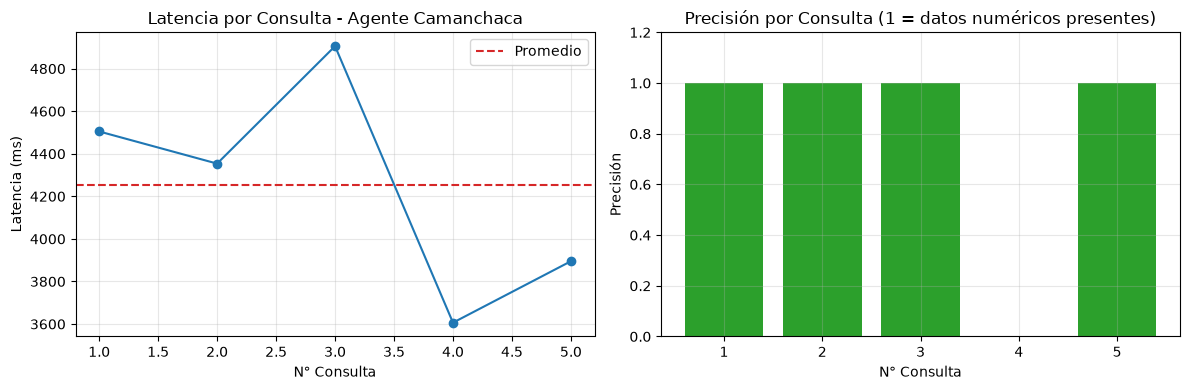

✓ Dashboard guardado como 'dashboard_observabilidad_camanchaca.png'


In [8]:
# ============================================================
# SECCIÓN 7: VISUALIZACIÓN DE MÉTRICAS
# Dashboard básico para la defensa (Ítem II del EFT)
# ============================================================

import matplotlib.pyplot as plt

registros = agente_observable.metricas.registros

if registros:
    consultas_idx = list(range(1, len(registros) + 1))
    latencias     = [r.tiempo_respuesta_ms for r in registros]
    precision     = [1 if r.contiene_datos else 0 for r in registros]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(consultas_idx, latencias, marker="o", color="tab:blue")
    axes[0].axhline(y=sum(latencias)/len(latencias), color="tab:red", linestyle="--", label="Promedio")
    axes[0].set_title("Latencia por Consulta - Agente Camanchaca")
    axes[0].set_xlabel("N° Consulta")
    axes[0].set_ylabel("Latencia (ms)")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].bar(consultas_idx, precision, color="tab:green")
    axes[1].set_title("Precisión por Consulta (1 = datos numéricos presentes)")
    axes[1].set_xlabel("N° Consulta")
    axes[1].set_ylabel("Precisión")
    axes[1].set_ylim(0, 1.2)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("dashboard_observabilidad_camanchaca.png", dpi=100)
    plt.show()

    print("✓ Dashboard guardado como 'dashboard_observabilidad_camanchaca.png'")
else:
    print("No hay registros para graficar.")


## Conclusión - IL3.1 / IE9

Este notebook implementó un sistema de **observabilidad** para el agente Camanchaca, cubriendo los tres pilares solicitados por el indicador IE9:

- **Precisión**: medida como el porcentaje de respuestas que incluyen datos climáticos concretos (temperatura, viento, lluvia) en lugar de respuestas genéricas.
- **Latencia**: tiempo de respuesta de cada consulta, con promedio, máximo, mínimo y coeficiente de variación.
- **Consistencia**: evaluada mediante el coeficiente de variación de la latencia entre consultas con distinta complejidad (clima actual vs. evaluación de operación).

Los resultados de este notebook alimentan el análisis de trazabilidad (IL3.2) y las propuestas de mejora (IL3.4) presentadas en los siguientes notebooks del proyecto.